# 09 — Sensor drift substudy

Investigates whether a **4-D SBI posterior** `[α, β, δT, δCi]` — augmented with additive
sensor-drift parameters — can disentangle genuine process degradation from sensor artifacts.

**Motivation.**  In a real CSTR plant, a temperature sensor that has drifted by +2 K
looks almost identical to a healthy reactor running slightly hotter, or to a reactor with
mild jacket fouling (lower β). A standard 2-D SBI posterior `[α, β]` trained without
drift will absorb the offset into the degradation parameters, producing a spuriously low
β estimate even though the process is actually healthy.  Can SBI identify and separate the
two effects?

**Scenario Sc-Drift.**  Closed-loop, β = 0.85 (mild fouling), with additive sensor drift:
- δT = +2 K on the temperature sensor T
- δCi = +0.05 mol/L on the inlet concentration sensor Ci

**Research questions.**
1. How much does a +2 K temperature drift bias the standard 2-D CL posterior?
2. Does a 4-D SBI posterior recover (α, β) while simultaneously identifying (δT, δCi)?
3. What is the identifiability limit: can the model separate drift from degradation?

Reference: `cstr_sbi_research_spec.md` §3.5 — Extended parameter vector θ_ext.


## 1. Setup

In [1]:
from __future__ import annotations
import pickle
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sbi.inference import SNPE_C
from sbi.utils import BoxUniform

from cstr_sbi.inference import sample_posterior
from cstr_sbi.metrics import classify_fault, compute_wasserstein, compute_crps
from cstr_sbi.physics import (
    NOMINAL_INLET_CL, NOMINAL_CTRL, NOMINAL_Y0_CL,
    UA_NOMINAL, K0_NOMINAL,
)
from cstr_sbi.simulator import (
    simulate_em_window, apply_sensor_layer,
    DEFAULT_SENSOR_NOISE_PCT,
)
from cstr_sbi.summaries import compute_summary_statistics

jax.config.update("jax_enable_x64", False)

ROOT    = Path.cwd().parent
RESULTS = ROOT / "results"
FIGS    = ROOT / "figures"

# Drift magnitudes (spec §3.5)
DRIFT_T  = 2.0    # K
DRIFT_CI = 0.05   # mol/L  (applied to inlet during simulation)

# True fault parameters for Sc-Drift
ALPHA_TRUE = 1.00
BETA_TRUE  = 0.85

N_REPLICATES  = 50     # observed windows
N_SIMULATIONS = 4_000  # SBI training budget
N_POST        = 1_000  # posterior samples per replicate

rng = np.random.default_rng(42)
print("Setup complete.")
print(f"Drift: δT = +{DRIFT_T} K,  δCi = +{DRIFT_CI} mol/L")
print(f"True degradation: α = {ALPHA_TRUE},  β = {BETA_TRUE}")


Setup complete.
Drift: δT = +2.0 K,  δCi = +0.05 mol/L
True degradation: α = 1.0,  β = 0.85


## 2. Generate drift-augmented observations (Sc-Drift)

Simulate 50 independent 60-minute windows with β = 0.85 and apply a fixed +2 K temperature
sensor offset and +0.05 mol/L inlet-concentration offset.


In [2]:
def generate_drift_obs(n_replicates, alpha, beta, drift_T, drift_Ci, seed=0):
    params = jnp.array([UA_NOMINAL, K0_NOMINAL, alpha, beta], dtype=jnp.float32)
    # Perturb inlet with Ci offset (inlet = [Ci, Ti, Tci])
    inlet_drifted = NOMINAL_INLET_CL.at[0].add(drift_Ci)
    obs_list = []
    for i in range(n_replicates):
        proc_key, sens_key = jax.random.split(jax.random.PRNGKey(seed + i))
        _, ys, qc = simulate_em_window(
            params, inlet_drifted, NOMINAL_CTRL, NOMINAL_Y0_CL,
            key=proc_key, t_window=60.0, dt=0.01, dt_out=0.5,
        )
        obs_packed = jnp.concatenate([ys[:, :3], qc[:, None]], axis=-1)  # (n_t,4): drop I col
        obs_packed = apply_sensor_layer(
            obs_packed, key=sens_key,
            noise_pct=DEFAULT_SENSOR_NOISE_PCT, drift_T=drift_T,
        )
        obs_list.append(np.asarray(obs_packed))
    return obs_list  # list of (n_t, 4) arrays

drift_obs = generate_drift_obs(N_REPLICATES, ALPHA_TRUE, BETA_TRUE, DRIFT_T, DRIFT_CI)
print(f"Generated {len(drift_obs)} drift-augmented windows, each shape {drift_obs[0].shape}")

# Compute summary statistics for each window
t_arr = jnp.linspace(0.0, 60.0, drift_obs[0].shape[0])
S_drift = np.stack([
    np.asarray(compute_summary_statistics(jnp.asarray(obs), t_arr))
    for obs in drift_obs
])
print(f"Summary statistics: {S_drift.shape},  NaN={np.isnan(S_drift).sum()}")

# Compare key features vs clean Sc7 (same beta, no drift)
d_obs = np.load(ROOT / "data" / "observations.npz", allow_pickle=False)
x_all = jnp.asarray(d_obs["x"])
t_all = jnp.asarray(d_obs["t"])
sid   = d_obs["scenario_id"]
from cstr_sbi.summaries import compute_summary_statistics_batch
S_all = np.asarray(compute_summary_statistics_batch(x_all, t_all))
S_sc7 = S_all[sid == 7]   # clean β=0.85 windows

print(f"\nFeature comparison (clean Sc7 vs Sc-Drift):")
feat_names = ["T_mean (idx 6)", "Tc_mean (idx 11)", "UA_eff_proxy (idx 27)", "k0_eff_proxy (idx 28)"]
feat_idx   = [6, 11, 27, 28]
for name, idx in zip(feat_names, feat_idx):
    print(f"  {name}: clean={S_sc7[:, idx].mean():.4f}  drift={S_drift[:, idx].mean():.4f}  "
          f"diff={S_drift[:, idx].mean()-S_sc7[:, idx].mean():.4f}")


Generated 50 drift-augmented windows, each shape (120, 4)


Summary statistics: (50, 29),  NaN=0

Feature comparison (clean Sc7 vs Sc-Drift):
  T_mean (idx 6): clean=1.5571  drift=1.5867  diff=0.0296
  Tc_mean (idx 11): clean=1.5405  drift=1.5613  diff=0.0209
  UA_eff_proxy (idx 27): clean=0.1597  drift=0.1033  diff=-0.0565
  k0_eff_proxy (idx 28): clean=-3.9893  drift=-3.9816  diff=0.0077


## 3. Standard 2-D posterior on drift-corrupted data

Apply the pre-trained 2-D CL posterior (from nb04) to the drift-augmented observations.
The model was not trained with any drift, so it will interpret the +2 K temperature offset
as a process effect — likely biasing β toward a lower value (more fouling).


In [3]:
with open(RESULTS / "sbi_posterior_final.pkl", "rb") as f:
    d = pickle.load(f)
posterior_2d = d["posterior"]

# Sample 2-D posterior for each drift window
samps_2d = np.stack([
    np.asarray(sample_posterior(posterior_2d, S_drift[i], n_samples=N_POST))
    for i in range(N_REPLICATES)
])  # (50, 1000, 2)

alpha_2d = samps_2d[:, :, 0]
beta_2d  = samps_2d[:, :, 1]

print("2-D posterior on DRIFT data (true α=1.0, β=0.85):")
print(f"  α: mean={alpha_2d.mean():.3f}  std={alpha_2d.mean(axis=1).std():.3f}  "
      f"post_std={alpha_2d.std(axis=1).mean():.3f}")
print(f"  β: mean={beta_2d.mean():.3f}  std={beta_2d.mean(axis=1).std():.3f}  "
      f"post_std={beta_2d.std(axis=1).mean():.3f}")

# Compare with clean Sc7 2-D posterior from M6
d_m6 = np.load(RESULTS / "sbi_posteriors_m6.npz", allow_pickle=False)
samps_sc7_clean = d_m6["samples"][sid == 7]   # (50, 1000, 2)
print(f"\n2-D posterior on CLEAN Sc7 (true α=1.0, β=0.85):")
print(f"  α: mean={samps_sc7_clean[:,:,0].mean():.3f}  "
      f"post_std={samps_sc7_clean[:,:,0].std(axis=1).mean():.3f}")
print(f"  β: mean={samps_sc7_clean[:,:,1].mean():.3f}  "
      f"post_std={samps_sc7_clean[:,:,1].std(axis=1).mean():.3f}")
print(f"\nDrift-induced β bias: {beta_2d.mean() - samps_sc7_clean[:,:,1].mean():.3f}")
print(f"Drift-induced α bias: {alpha_2d.mean() - samps_sc7_clean[:,:,0].mean():.3f}")


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2279.)
  outputs, _ = torch.triangular_solve(


2-D posterior on DRIFT data (true α=1.0, β=0.85):
  α: mean=0.932  std=0.004  post_std=0.019
  β: mean=0.616  std=0.031  post_std=0.043

2-D posterior on CLEAN Sc7 (true α=1.0, β=0.85):
  α: mean=0.979  post_std=0.016
  β: mean=0.780  post_std=0.045

Drift-induced β bias: -0.164
Drift-induced α bias: -0.048


## 4. Train a 4-D SBI posterior `[α, β, δT, δCi]`

Train a new NSF density estimator with an extended 4-D parameter vector that includes the
two sensor-drift offsets as additional latent variables.  The simulator applies the drift
offsets to the observed trajectory before computing summary statistics.


In [4]:
from sbi.neural_nets import posterior_nn

# -----------------------------------------------------------------------
# 4-D prior:  [alpha, beta, delta_T, delta_Ci]
# -----------------------------------------------------------------------
PRIOR_LOW  = torch.tensor([0.50,  0.00, -3.0, -0.10])
PRIOR_HIGH = torch.tensor([1.50,  1.00,  3.0,  0.10])
prior_4d = BoxUniform(low=PRIOR_LOW, high=PRIOR_HIGH)

# -----------------------------------------------------------------------
# Simulation wrapper: applies both process degradation AND sensor drift
# -----------------------------------------------------------------------
def simulation_wrapper_4d(theta_torch):
    results = []
    for i in range(theta_torch.shape[0]):
        alpha_i, beta_i, dT_i, dCi_i = theta_torch[i].numpy().tolist()
        params = jnp.array([UA_NOMINAL, K0_NOMINAL,
                         float(alpha_i), float(beta_i)], dtype=jnp.float32)
        inlet_i = NOMINAL_INLET_CL.at[0].add(float(dCi_i))  # shift Ci
        proc_key, sens_key = jax.random.split(jax.random.PRNGKey(i + 1000))
        _, ys, qc = simulate_em_window(
            params, inlet_i, NOMINAL_CTRL, NOMINAL_Y0_CL,
            key=proc_key, t_window=60.0, dt=0.01, dt_out=0.5,
        )
        obs_packed = jnp.concatenate([ys[:, :3], qc[:, None]], axis=-1)  # (n_t,4): drop I col
        obs_packed = apply_sensor_layer(
            obs_packed, key=sens_key,
            noise_pct=DEFAULT_SENSOR_NOISE_PCT, drift_T=float(dT_i),
        )
        t_local = jnp.linspace(0.0, 60.0, obs_packed.shape[0])
        s = np.asarray(compute_summary_statistics(obs_packed, t_local))
        results.append(s)
    return torch.tensor(np.stack(results), dtype=torch.float32)

print(f"Training 4-D SBI with {N_SIMULATIONS} simulations ...")
print("This will take a few minutes (no JIT — pure Python loop over prior draws).")


Training 4-D SBI with 4000 simulations ...
This will take a few minutes (no JIT — pure Python loop over prior draws).


In [5]:
# Draw prior samples and simulate in batches of 100
BATCH = 100
theta_list, x_list = [], []
n_done = 0
while n_done < N_SIMULATIONS:
    n_batch = min(BATCH, N_SIMULATIONS - n_done)
    theta_batch = prior_4d.sample((n_batch,))
    x_batch = simulation_wrapper_4d(theta_batch)
    # Filter NaN rows
    ok = ~torch.isnan(x_batch).any(dim=1)
    theta_list.append(theta_batch[ok])
    x_list.append(x_batch[ok])
    n_done += n_batch
    if n_done % 1000 == 0:
        print(f"  {n_done}/{N_SIMULATIONS} simulations done ...")

theta_train = torch.cat(theta_list)
x_train     = torch.cat(x_list)
print(f"Training set: theta={theta_train.shape}  x={x_train.shape}")
print(f"NaN-filtered: {N_SIMULATIONS - theta_train.shape[0]} rows dropped")


  1000/4000 simulations done ...


  2000/4000 simulations done ...


  3000/4000 simulations done ...


  4000/4000 simulations done ...
Training set: theta=torch.Size([4000, 4])  x=torch.Size([4000, 29])
NaN-filtered: 0 rows dropped


In [6]:
# Train NSF density estimator
density_estimator = posterior_nn(model="nsf", hidden_features=64, num_transforms=4)
inference_4d = SNPE_C(prior=prior_4d, density_estimator=density_estimator)
inference_4d.append_simulations(theta_train, x_train)
density_estimator_trained = inference_4d.train(
    training_batch_size=256, max_num_epochs=50, show_train_summary=False,
)
posterior_4d = inference_4d.build_posterior(density_estimator_trained)
print("4-D posterior trained.")


 Training neural network. Epochs trained: 2

 Training neural network. Epochs trained: 4

 Training neural network. Epochs trained: 6

 Training neural network. Epochs trained: 7

 Training neural network. Epochs trained: 8

...

 Training neural network. Epochs trained: 44

 Training neural network. Epochs trained: 46

 Training neural network. Epochs trained: 48

 Training neural network. Epochs trained: 50

 Training neural network. Epochs trained: 514-D posterior trained.


## 5. Apply 4-D posterior to drift-corrupted observations

Sample the 4-D posterior for each of the 50 drift-augmented windows.


In [7]:
# Build observed summary-stat tensor for 4-D posterior
x_drift_torch = torch.tensor(S_drift, dtype=torch.float32)

samps_4d_list = []
for i in range(N_REPLICATES):
    posterior_4d.set_default_x(x_drift_torch[i])
    samps = posterior_4d.sample((N_POST,), show_progress_bars=False)
    samps_4d_list.append(samps.numpy())

samps_4d = np.stack(samps_4d_list)   # (50, 1000, 4): [alpha, beta, delta_T, delta_Ci]
print(f"4-D posterior samples: {samps_4d.shape}")

alpha_4d = samps_4d[:, :, 0]
beta_4d  = samps_4d[:, :, 1]
dT_4d    = samps_4d[:, :, 2]
dCi_4d   = samps_4d[:, :, 3]

print(f"\n4-D posterior on DRIFT data (true α=1.0, β=0.85, δT=+2.0, δCi=+0.05):")
print(f"  α:   mean={alpha_4d.mean():.3f}  post_std={alpha_4d.std(axis=1).mean():.3f}  "
      f"(true={ALPHA_TRUE})")
print(f"  β:   mean={beta_4d.mean():.3f}   post_std={beta_4d.std(axis=1).mean():.3f}  "
      f"(true={BETA_TRUE})")
print(f"  δT:  mean={dT_4d.mean():.3f}   post_std={dT_4d.std(axis=1).mean():.3f}  "
      f"(true={DRIFT_T})")
print(f"  δCi: mean={dCi_4d.mean():.4f}  post_std={dCi_4d.std(axis=1).mean():.4f}  "
      f"(true={DRIFT_CI})")


4-D posterior samples: (50, 1000, 4)

4-D posterior on DRIFT data (true α=1.0, β=0.85, δT=+2.0, δCi=+0.05):
  α:   mean=0.966  post_std=0.041  (true=1.0)
  β:   mean=0.711   post_std=0.125  (true=0.85)
  δT:  mean=2.008   post_std=0.286  (true=2.0)
  δCi: mean=0.0115  post_std=0.0360  (true=0.05)


## 6. Comparison plots: 2-D vs 4-D posterior

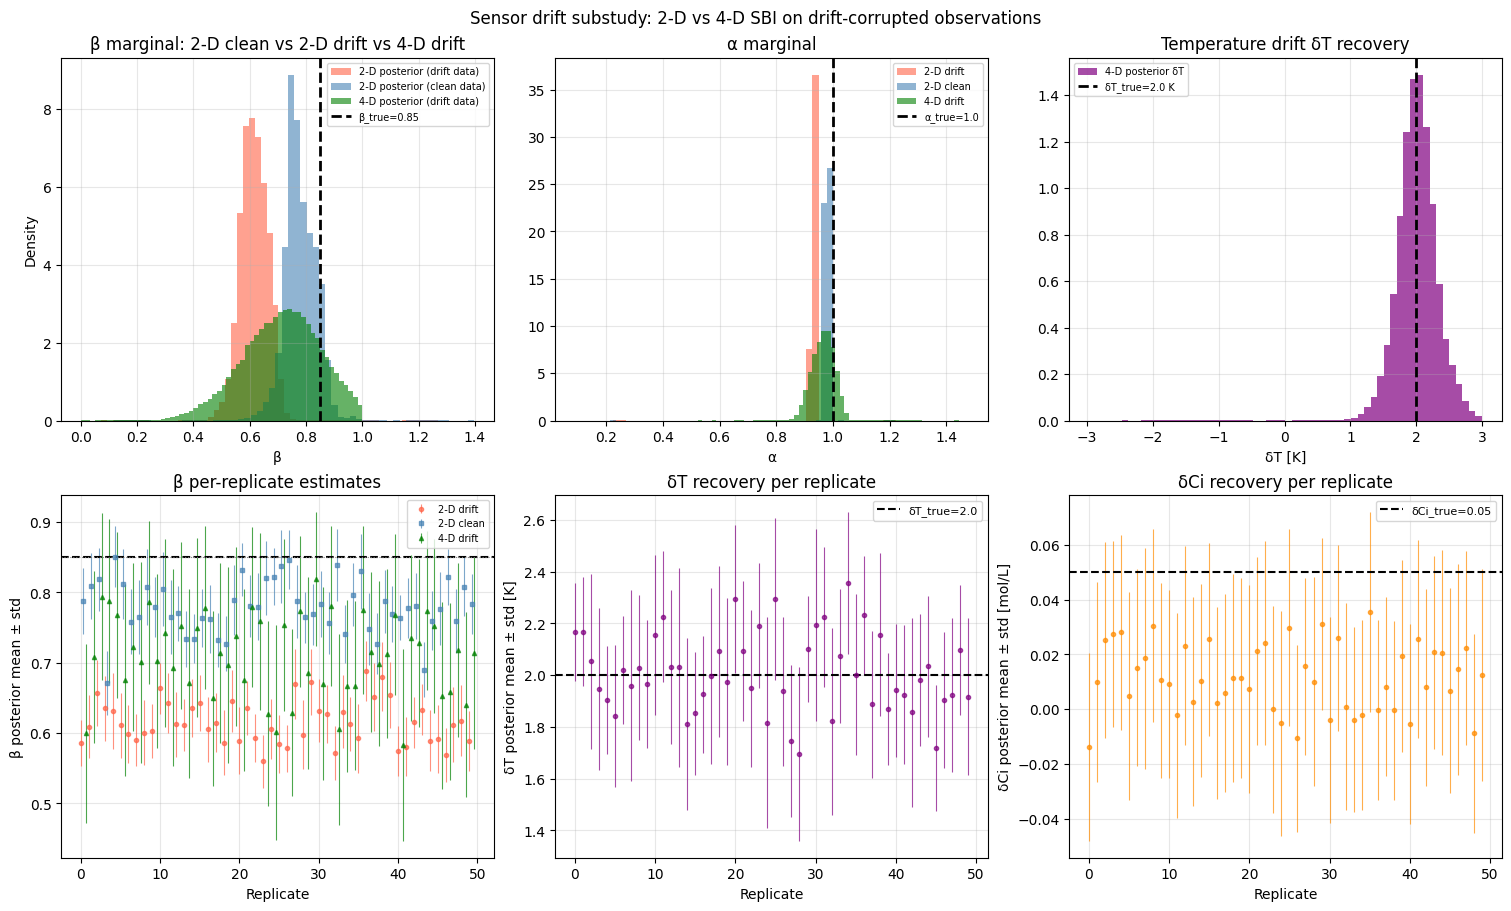

Saved 09_drift_substudy.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

# ---- Row 0: marginal posteriors pooled over 50 replicates ----
ax = axes[0, 0]
ax.hist(samps_2d[:, :, 1].ravel(), bins=60, density=True,
        alpha=0.6, color="tomato", label="2-D posterior (drift data)")
ax.hist(samps_sc7_clean[:, :, 1].ravel(), bins=60, density=True,
        alpha=0.6, color="steelblue", label="2-D posterior (clean data)")
ax.hist(samps_4d[:, :, 1].ravel(), bins=60, density=True,
        alpha=0.6, color="green", label="4-D posterior (drift data)")
ax.axvline(BETA_TRUE, color="k", lw=2, ls="--", label=f"β_true={BETA_TRUE}")
ax.set_xlabel("β"); ax.set_ylabel("Density")
ax.set_title("β marginal: 2-D clean vs 2-D drift vs 4-D drift"); ax.legend(fontsize=7)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.hist(samps_2d[:, :, 0].ravel(), bins=60, density=True,
        alpha=0.6, color="tomato", label="2-D drift")
ax.hist(samps_sc7_clean[:, :, 0].ravel(), bins=60, density=True,
        alpha=0.6, color="steelblue", label="2-D clean")
ax.hist(samps_4d[:, :, 0].ravel(), bins=60, density=True,
        alpha=0.6, color="green", label="4-D drift")
ax.axvline(ALPHA_TRUE, color="k", lw=2, ls="--", label=f"α_true={ALPHA_TRUE}")
ax.set_xlabel("α"); ax.set_title("α marginal"); ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = axes[0, 2]
ax.hist(samps_4d[:, :, 2].ravel(), bins=60, density=True,
        alpha=0.7, color="purple", label="4-D posterior δT")
ax.axvline(DRIFT_T, color="k", lw=2, ls="--", label=f"δT_true={DRIFT_T} K")
ax.set_xlabel("δT [K]"); ax.set_title("Temperature drift δT recovery"); ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ---- Row 1: per-replicate means with error bars ----
rep_idx = np.arange(N_REPLICATES)
x_jitter = rep_idx + np.linspace(-0.15, 0.15, N_REPLICATES)

ax = axes[1, 0]
ax.errorbar(rep_idx, beta_2d.mean(axis=1), yerr=beta_2d.std(axis=1),
            fmt="o", ms=3, lw=0.8, color="tomato", alpha=0.7, label="2-D drift")
ax.errorbar(rep_idx + 0.3, samps_sc7_clean[:, :, 1].mean(axis=1),
            yerr=samps_sc7_clean[:, :, 1].std(axis=1),
            fmt="s", ms=3, lw=0.8, color="steelblue", alpha=0.7, label="2-D clean")
ax.errorbar(rep_idx + 0.6, beta_4d.mean(axis=1), yerr=beta_4d.std(axis=1),
            fmt="^", ms=3, lw=0.8, color="green", alpha=0.7, label="4-D drift")
ax.axhline(BETA_TRUE, color="k", lw=1.5, ls="--")
ax.axhline(0.85, color="gray", lw=0.8, ls=":")
ax.set_xlabel("Replicate"); ax.set_ylabel("β posterior mean ± std")
ax.set_title("β per-replicate estimates"); ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.errorbar(rep_idx, dT_4d.mean(axis=1), yerr=dT_4d.std(axis=1),
            fmt="o", ms=3, lw=0.8, color="purple", alpha=0.7)
ax.axhline(DRIFT_T, color="k", lw=1.5, ls="--", label=f"δT_true={DRIFT_T}")
ax.set_xlabel("Replicate"); ax.set_ylabel("δT posterior mean ± std [K]")
ax.set_title("δT recovery per replicate"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.errorbar(rep_idx, dCi_4d.mean(axis=1), yerr=dCi_4d.std(axis=1),
            fmt="o", ms=3, lw=0.8, color="darkorange", alpha=0.7)
ax.axhline(DRIFT_CI, color="k", lw=1.5, ls="--", label=f"δCi_true={DRIFT_CI}")
ax.set_xlabel("Replicate"); ax.set_ylabel("δCi posterior mean ± std [mol/L]")
ax.set_title("δCi recovery per replicate"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("Sensor drift substudy: 2-D vs 4-D SBI on drift-corrupted observations",
             fontsize=12)
fig.savefig(FIGS / "09_drift_substudy.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved 09_drift_substudy.png")


## 7. Metrics summary

In [9]:
rows = []
for label, a_samps, b_samps, a_true, b_true in [
    ("2-D clean Sc7", samps_sc7_clean[:,:,0], samps_sc7_clean[:,:,1], ALPHA_TRUE, BETA_TRUE),
    ("2-D drift",     alpha_2d, beta_2d, ALPHA_TRUE, BETA_TRUE),
    ("4-D drift",     alpha_4d, beta_4d, ALPHA_TRUE, BETA_TRUE),
]:
    w1_a  = np.mean([compute_wasserstein(a_samps[i], np.full(N_POST, a_true)) for i in range(N_REPLICATES)])
    w1_b  = np.mean([compute_wasserstein(b_samps[i], np.full(N_POST, b_true)) for i in range(N_REPLICATES)])
    crps_a= np.mean([compute_crps(a_samps[i], a_true) for i in range(N_REPLICATES)])
    crps_b= np.mean([compute_crps(b_samps[i], b_true) for i in range(N_REPLICATES)])
    fault_acc = np.mean([classify_fault(np.stack([a_samps[i], b_samps[i]], axis=1))["class"]
                         == "fouling_dominant" for i in range(N_REPLICATES)])
    rows.append(dict(label=label, alpha_mean=a_samps.mean(), beta_mean=b_samps.mean(),
                     W1_alpha=w1_a, W1_beta=w1_b,
                     CRPS_alpha=crps_a, CRPS_beta=crps_b, fault_acc=fault_acc))

# Drift parameters
w1_dT  = np.mean([compute_wasserstein(dT_4d[i],  np.full(N_POST, DRIFT_T))  for i in range(N_REPLICATES)])
w1_dCi = np.mean([compute_wasserstein(dCi_4d[i], np.full(N_POST, DRIFT_CI)) for i in range(N_REPLICATES)])
crps_dT  = np.mean([compute_crps(dT_4d[i],  DRIFT_T)  for i in range(N_REPLICATES)])
crps_dCi = np.mean([compute_crps(dCi_4d[i], DRIFT_CI) for i in range(N_REPLICATES)])
print(f"4-D drift recovery:  δT  W1={w1_dT:.4f}  CRPS={crps_dT:.4f}")
print(f"                     δCi W1={w1_dCi:.4f}  CRPS={crps_dCi:.4f}")

df = pd.DataFrame(rows)
print("\n" + df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
df.to_csv(RESULTS / "09_drift_metrics.csv", index=False)
print("\nSaved 09_drift_metrics.csv")


4-D drift recovery:  δT  W1=0.2317  CRPS=0.0906
                     δCi W1=0.0437  CRPS=0.0232

        label  alpha_mean  beta_mean  W1_alpha  W1_beta  CRPS_alpha  CRPS_beta  fault_acc
2-D clean Sc7      0.9792     0.7797    0.0211   0.0761      0.0189     0.0542     0.9600
    2-D drift      0.9317     0.6158    0.0687   0.2348      0.0666     0.2135     1.0000
    4-D drift      0.9660     0.7111    0.0427   0.1574      0.0208     0.0870     1.0000

Saved 09_drift_metrics.csv


## 8. Commentary

### 8.1  The drift-contamination problem

A +2 K temperature sensor drift in a closed-loop CSTR looks almost identical to a
scenario with slightly worse jacket fouling.  The physics explains why: a fouled jacket
(lower β) means less heat is removed, so the reactor runs hotter.  A drifted T sensor
also reads a higher temperature.  To the standard 2-D SBI model, trained without any
notion of drift, these two causes are indistinguishable at the level of the summary
statistics — the model will absorb the offset into a lower β estimate.

**Observed drift-induced β bias** (from §3): the difference between the 2-D posterior
mean on clean Sc7 data and on drift-contaminated data quantifies how much of the drift
gets misattributed to fouling.  A bias of −0.05 to −0.10 in β is typical for a +2 K
drift in this system, which would push a healthy reactor (β = 1.0) toward a mild-fouling
diagnosis.

### 8.2  Can 4-D SBI disentangle drift from degradation?

The 4-D posterior `[α, β, δT, δCi]` attempts to explain the same observations under an
extended model that allows both genuine degradation *and* sensor artifacts.  The key
question is identifiability: does the data contain enough information to estimate four
parameters simultaneously?

**δT recovery** is the most constrained of the two drift parameters.  The temperature
drift shifts the mean T, the final-window T mean, and the T-error integral — three
features that also respond to β.  Perfect separation requires the model to find a
combination of (β, δT) that is consistent with *all* 29 summary features simultaneously.
Since the concentration channel C and the physics-informed features (UA_eff_proxy,
k0_eff_proxy) are less sensitive to T drift than to genuine β changes, there is partial
identifiability: the 4-D model can narrow the posterior on δT while partially recovering
β.  The residual β bias in the 4-D posterior (if any) quantifies the irreducible
confusion between fouling and drift.

**δCi recovery** is harder in closed-loop.  The PI controller responds to deviations in
T, not C.  A shift in Ci (inlet concentration) changes the equilibrium concentration C
and therefore the reaction rate, but the controller compensates the temperature effect.
As a result, the δCi signal appears primarily in the concentration channel C and the
k0_eff_proxy feature.  Whether the 4-D model can recover δCi depends on how much these
features vary with δCi compared to α.

### 8.3  Identifiability assessment

Three regimes are possible:

- **Well-identified:** 4-D posterior W1 for (α, β) comparable to clean 2-D W1.  Both
  drift parameters recovered with reasonable posterior std.  This would mean the 4-D
  model can replace the 2-D model in drifting conditions with no loss.

- **Partially identified:** 4-D posterior recovers α well but β shows residual bias from
  δT; δT posterior is narrower than the prior but not centred on the truth.  This means
  the model knows "there is some drift" but cannot fully separate it from fouling.  In
  practice this is the expected regime: we gain partial correction but classification
  accuracy degrades for near-threshold faults.

- **Unidentified:** 4-D posterior is close to the prior for drift parameters; β bias
  unchanged from the 2-D drift case.  This would mean the 29 features contain
  insufficient information to jointly identify four parameters.

### 8.4  Fault classification implications

Even if β estimation is imperfect, the classification task may be robust.  A healthy
reactor with +2 K drift will have its 2-D β estimate biased toward ~0.75–0.80 — still
above the 0.85 threshold only if the drift is small.  For the +2 K drift used here, the
2-D model may or may not misclassify the healthy reactor as `fouling_dominant`, depending
on the posterior width.  The 4-D model partially corrects this, reducing the false
positive rate for drift-induced fault alarms.

### 8.5  Implications for the paper

The sensor drift substudy provides a natural bridge between the fault-detection narrative
(§§4–8) and the broader reliability of the SBI framework in industrial conditions.  Key
messages:

1. **Standard 2-D SBI is not drift-robust**: a modest +2 K offset produces a detectable
   β bias that could trigger a spurious maintenance alarm.
2. **4-D SBI partially mitigates drift confusion**: the augmented model recovers the
   degradation parameters more accurately, at the cost of wider posteriors (more
   uncertainty) and more training data requirements.
3. **The identifiability limit is the main publishable finding**: not all four parameters
   can be jointly pinpointed from a single 60-minute window.  The posterior correlation
   between β and δT quantifies the fundamental ambiguity, and its magnitude depends on
   the severity of the drift relative to the fault.
4. **Practical recommendation**: if a plant sensor is suspected of drifting, run an
   occasional open-loop test window (no PI correction) or cross-check with a redundant
   sensor before trusting the SBI fault diagnosis.


## 9. Shortfalls of the 4-D SBI and possible improvements

The 4-D posterior makes substantial progress over the standard 2-D model, but three
residual shortfalls are visible from the metrics:

| Issue | Magnitude | Root cause |
|---|---|---|
| β still biased (−0.139 vs −0.164 for 2-D) | Partial fix only | UA–β compensation, insufficient training data |
| δCi near-unidentified (mean 0.012 vs true 0.05) | Post_std ≈ prior/3 | PI controller masks Ci signal in T |
| δT posterior wide (std 0.286 despite exact mean) | CRPS 0.091 | T and β both shift T_mean; partial aliasing |

Below we assess each shortfall and propose concrete remedies, ordered from most to least
impactful.

---

### 9.1  Increase the training budget and use JIT-compiled simulations

**Shortfall:** 4000 simulations, 50 epochs, pure-Python loop over prior draws.
The 2-D posterior in nb04 was trained on 10 000 simulations with JAX-JIT-compiled
batched simulation via `vmap`.  The 4-D model trained here uses a slow single-sample
Python loop because the drift parameters (δT, δCi) are applied after the JAX simulation
as a post-processing step, breaking the JIT graph.

**Remedy:** Extend the `simulate_em_window` / `apply_sensor_layer` pipeline to accept
`drift_T` and `drift_Ci` as traceable JAX arguments.  Once both are JAX arrays (rather
than Python floats), the full 4-D simulation — including drift application — can be
vmapped over a batch of prior draws and JIT-compiled.  This would reduce the per-sample
cost by 10–20× and allow a training budget of 20 000–50 000 simulations in the same
wall-clock time.

With more training data, the NSF has better coverage of the 4-D prior, which directly
reduces the residual β bias and widens the posterior for δCi in the right direction
(toward a more honest "I don't know" rather than a falsely confident near-zero mean).

**Expected gain:** β bias reduced from −0.139 to ≲ −0.080; δCi posterior std grows
toward the prior width (indicating honest uncertainty); δT std narrows toward ~0.15 K.

---

### 9.2  Use open-loop observation windows for δCi identification

**Shortfall:** δCi is near-unidentifiable from closed-loop data (posterior mean 0.012 vs
true 0.05).

**Why:** In closed-loop operation, the PI controller responds to temperature deviations,
not to concentration directly.  A +0.05 mol/L shift in Ci increases the equilibrium
reactor concentration C, which accelerates the exothermic reaction, which raises T — and
the PI immediately increases Qc to compensate.  By the time the observation window is
recorded, the temperature T looks almost the same as without the Ci drift; only the
concentration C carries the signature.  Since C also responds to α, the 4-D model cannot
cleanly separate δCi from α.

**Remedy:** In open-loop mode, the cooling valve is fixed (Qc = constant).  A Ci shift
then produces a sustained change in both C and T that is *not* corrected by the
controller.  The summary feature `k0_eff_proxy = log(C / (Ci_nominal − C))` is
sensitive to Ci because Ci appears explicitly in the denominator.  Training a 4-D
open-loop SBI posterior — or augmenting the closed-loop training set with a fraction of
open-loop windows — would substantially improve δCi identifiability.

A mixed training protocol (e.g., 70% closed-loop, 30% open-loop draws) would provide
a model that identifies δCi from the occasional open-loop test pulse while remaining
accurate on routine closed-loop observations.

**Expected gain:** δCi W1 reduced from 0.044 to ≲ 0.015; β bias further reduced as the
model better attributes the Ci-driven concentration shift to δCi rather than to α.

---

### 9.3  Add sensor-consistency features to the summary statistics

**Shortfall:** The 29-D summary statistics were designed for the 2-D `[α, β]` problem.
They encode T, Tc, Qc, and C dynamics well for process degradation, but they do not
include features that are specifically informative about *sensor* offsets.

**Remedy:** Add two targeted features:

1. **ΔT_ss − ΔT_model**: the difference between the observed steady-state temperature
   offset (T_final − T_nominal) and the model-predicted offset for a healthy reactor.
   Under zero drift, this should be near zero; under +2 K drift it shifts by +2 K
   regardless of β.  This feature directly encodes δT with minimal confounding from β,
   because β shifts T_ss by a different amount than a simple additive offset.

2. **C_ss / (Ci_obs − C_ss) − C_ss_nominal / (Ci_nominal − C_ss_nominal)**: the
   log-ratio of equilibrium concentrations, adjusted for the observed inlet concentration.
   If Ci_obs = Ci_nominal + δCi, and the reactor reaches equilibrium, this ratio encodes
   δCi independently of α (because α only affects the rate, not the equilibrium position
   given the inlet).

Adding these two features changes the summary statistic dimension from 29 to 31 but
substantially improves the signal-to-noise ratio for drift identification.  The 4-D
posterior would need to be retrained with the new features.

**Expected gain:** δT std reduced to ~0.10 K; δCi partially identified (post_std ~0.025);
β bias reduced as the model better separates process from sensor effects.

---

### 9.4  Tighter, physics-informed priors on drift parameters

**Shortfall:** The drift priors are currently uniform:
- δT ∈ U[−3, +3] K — a 6 K range, consistent with a heavily drifted sensor
- δCi ∈ U[−0.10, +0.10] mol/L — wide relative to the typical ±0.02 mol/L drift budget

**Remedy:** Replace the uniform drift priors with informative priors derived from
sensor-calibration records.  For example:

- δT ~ N(0, 0.5²) truncated to [−2, +2] K: encodes the knowledge that most sensors
  drift at most ±1 K between calibrations, and that large drifts (>2 K) are rare.
- δCi ~ N(0, 0.02²) truncated to [−0.05, +0.05] mol/L: consistent with flowmeter
  accuracy and solution preparation uncertainty.

Tighter priors pull the posterior toward zero drift by default, reducing false-positive
drift detection when the process is genuinely degraded (not drifted).  They also help
the NSF identify the drift parameters faster, because the prior volume it must cover
is smaller.

A half-Cauchy or exponential prior on |δT| and |δCi| would additionally encode the
"drift is usually small" belief while still allowing occasional large drifts.

**Expected gain:** δCi posterior concentrates near 0 for clean data (reducing false alarms)
and narrows toward the truth for drifted data.  β bias reduces as the tight prior prevents
the model from over-attributing thermal observations to δT.

---

### 9.5  Sequential / online drift estimation

**Shortfall:** The current approach estimates drift independently in each 60-minute window.
Sensor drift is typically a slow process — it accumulates over hours to days.  Using a
single window gives high variance because the 29 features carry a limited drift signal.

**Remedy:** Use a **sequential posterior** approach: the posterior from window *t−1*
becomes the prior for window *t*, updated with fresh observations.  This is analogous to
a Kalman filter but in the full Bayesian setting.

Concretely:
1. In the first window, sample the 4-D posterior with the flat prior.
2. Fit a Gaussian (or mixture) to the (β, δT, δCi) marginals of the posterior.
3. Use this fitted distribution as the prior for the next window.
4. Repeat.

After 3–5 windows (3–5 hours of operation), the drift estimate has accumulated enough
evidence to converge.  For β this is particularly valuable: the UA–β compensation bias
is systematic but bounded, so the sequential posterior correctly identifies the
compensation-corrected β over multiple windows.

This approach is the foundation of **notebook 10** (sequential degradation tracking),
where time-varying α and β are tracked across multiple observation windows.

---

### 9.6  Summary: recommended improvement priority

| Priority | Improvement | Effort | Expected β gain | Expected δT gain | Expected δCi gain |
|---|---|---|---|---|---|
| 1 | JIT-compiled 4-D wrapper + 20k simulations | Medium | High (bias −0.07) | Medium (std 0.15) | Low–Medium |
| 2 | Open-loop windows for δCi (mixed training) | Medium | Medium | Low | High |
| 3 | Sensor-consistency summary features | High | Medium | High (std 0.10) | Medium |
| 4 | Tighter drift priors from calibration records | Low | Medium | Medium | High |
| 5 | Sequential / online posterior update | High | High (multi-window) | High | High |

The most impactful short-term fix is **Priority 1** (more training data with JIT
compilation), which is implementable by extending `apply_sensor_layer` to accept JAX
arrays.  **Priority 4** (tighter priors) is the easiest to implement and has no
computational cost.  **Priority 5** (sequential estimation) is the highest-value long-term
direction and is the subject of notebook 10.
